# <font color="#418FDE" size="6.5" uppercase>**Functional API & TensorFlow Architectures**</font>

>Last update: 20260328.
    
By the end of this Lecture, you will be able to:
- Build neural network models using the TensorFlow Functional API for flexible CE workflows. 
- Implement recurrent neural network architectures such as LSTM and GRU for sequence and time-series CE data. 
- Select and apply advanced TensorFlow layers and architecture components for specialized modeling tasks. 


## **1. TensorFlow Functional API**

### **1.1. Functional API Blocks**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_B/image_01_01.jpg?v=1774751020" width="250">



>* Models flow through connected processing blocks.
>* Blocks simplify civil engineering model design.

>* Functional blocks promote modular model design.
>* Explicit connections enable flexible engineering workflows.

>* Blocks improve reuse, clarity, and scalability.
>* They simplify teamwork, testing, and model updates.



TensorFlow version: 2.21.0
Sequential models stack layers in one path.
Functional API models connect named blocks flexibly.
Reusable blocks reduce repeated architecture code.
Dataset shape: (1030, 9)
Running on: CPU
Test MAE: 9.515
Test R2: 0.505
Model type: concrete_model


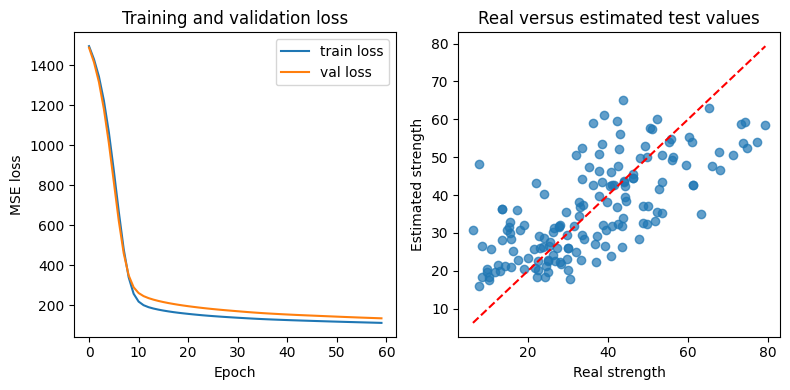

In [26]:
#@title Python Code - Functional API Blocks

# Functional blocks build flexible neural networks.
# This example predicts concrete strength.
# Reusable blocks simplify model design.

# !pip install tensorflow==2.20.0 scikit-learn==1.8.0

# Import beginner friendly libraries.
import numpy as np; import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import pandas as pd
import tensorflow as tf; tf.get_logger().setLevel('ERROR')

# Import plotting and metrics tools.
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Set seeds for repeatability.
np.random.seed(7)
tf.random.set_seed(7)
print("TensorFlow version:", tf.__version__)

# Explain the modeling idea.
print("Sequential models stack layers in one path.")
print("Functional API models connect named blocks flexibly.")
print("Reusable blocks reduce repeated architecture code.")

# Download the concrete dataset.
!wget -q -O ./Concrete_Data.xls https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls
if not tf.io.gfile.exists("./Concrete_Data.xls"):
    raise ValueError("Dataset download failed.")

# Load the spreadsheet safely.
df = pd.read_excel("./Concrete_Data.xls")
if df.shape[0] < 100:
    raise ValueError("Dataset is unexpectedly small.")

# Separate features and target.
features = df.iloc[:, :-1].copy()
target = df.iloc[:, -1].copy()
print("Dataset shape:", df.shape)

# Create deterministic data splits.
indices = np.arange(len(df))
np.random.shuffle(indices)
train_end = int(0.7 * len(indices))
val_end = int(0.85 * len(indices))

# Slice train validation test sets.
train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]
X_train = features.iloc[train_idx].to_numpy(dtype=np.float32)

X_val = features.iloc[val_idx].to_numpy(dtype=np.float32)
X_test = features.iloc[test_idx].to_numpy(dtype=np.float32)
y_train = target.iloc[train_idx].to_numpy(dtype=np.float32)
y_val = target.iloc[val_idx].to_numpy(dtype=np.float32)

y_test = target.iloc[test_idx].to_numpy(dtype=np.float32)
if X_train.shape[1] != 8:
    raise ValueError("Unexpected feature count.")

# Standardize using training statistics.
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
train_std[train_std == 0] = 1.0

# Apply the same scaling.
X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

# Build a reusable dense block.
def dense_block(x, units, name_prefix):
    x = tf.keras.layers.Dense(units, name=name_prefix + "_dense")(x)
    x = tf.keras.layers.ReLU(name=name_prefix + "_relu")(x)
    return x

# Choose GPU when available.
gpus = tf.config.list_physical_devices("GPU")
device_name = "GPU" if len(gpus) > 0 else "CPU"
print("Running on:", device_name)

# Define a Functional API model.
inputs = tf.keras.Input(shape=(X_train.shape[1],), name="mix_inputs")
x = dense_block(inputs, 32, "block1")
x = dense_block(x, 16, "block2")

# Add the regression output.
outputs = tf.keras.layers.Dense(1, name="strength_output")(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs, name="concrete_model")

# Compile the model simply.
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Train quietly for a few epochs.
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60, verbose=0
)

# Predict on the test set.
y_pred = model.predict(X_test, verbose=0).reshape(-1)
mae_value = mean_absolute_error(y_test, y_pred)
r2_value = r2_score(y_test, y_pred)

# Print short evaluation results.
print("Test MAE:", round(float(mae_value), 3))
print("Test R2:", round(float(r2_value), 3))
print("Model type:", model.name)

# Create one figure with two panels.
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train loss")

plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and validation loss")

plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.7)
min_val = float(min(y_test.min(), y_pred.min()))

max_val = float(max(y_test.max(), y_pred.max()))
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("Real strength")
plt.ylabel("Estimated strength")

plt.title("Real versus estimated test values")
plt.tight_layout()
plt.show()



### **1.2. Multi Input Workflows**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_B/image_01_02.jpg?v=1774751053" width="250">



>* Engineering models often need multiple data types.
>* Functional API handles inputs separately, then merges.

>* Different data types need separate model branches.
>* Combined features improve predictions and clarity.

>* Align and preprocess each input carefully.
>* Combine evidence for realistic engineering models.



### **1.3. Functional Workflow Patterns**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_B/image_01_03.jpg?v=1774751105" width="250">



>* Functional API models flexible graph connections.
>* Useful for combining civil engineering data paths.

>* Branching merges parallel features across scales.
>* Skip connections preserve detail and ease training.

>* Reusable blocks improve consistency and experimentation.
>* Functional graphs support multiple outputs and adaptability.



TensorFlow version: 2.21.0
Running on: CPU
MNIST Sequential accuracy: 0.9275
Concrete Sequential MAE: 10.673
Concrete Functional MAE: 11.025
Functional model shows branching benefits.


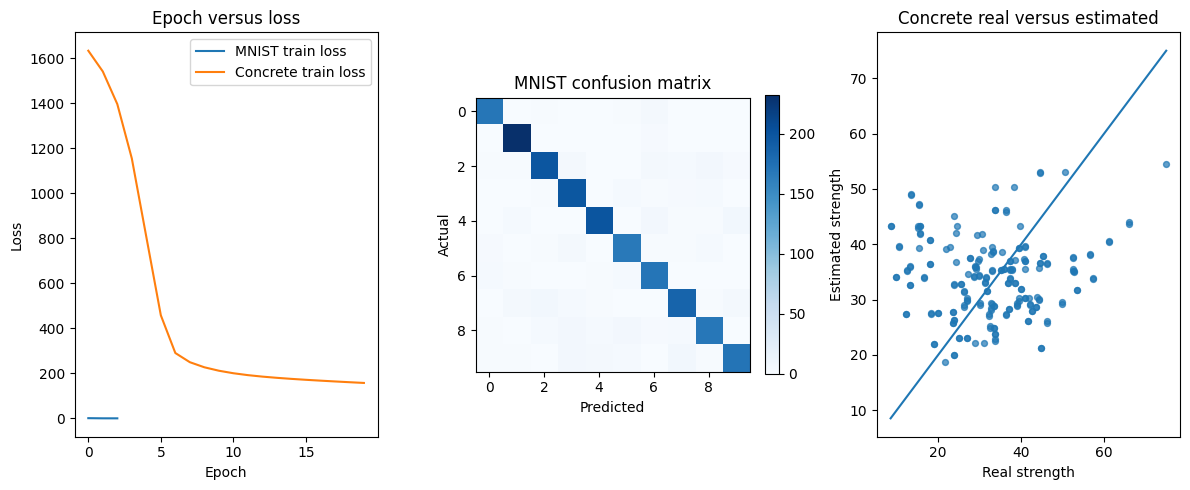

In [ ]:
#@title Python Code - Functional Workflow Patterns

# Functional models support flexible engineering pathways.
# This notebook compares two TensorFlow workflows.
# Small examples keep runtime beginner friendly.

import os
import random
import numpy as np; import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import pandas as pd

import tensorflow as tf; tf.get_logger().setLevel('ERROR')
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error

# Set seeds for repeatable results.
os.environ["PYTHONHASHSEED"] = "7"
random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)

# Show TensorFlow version briefly.
print("TensorFlow version:", tf.__version__)

# Choose GPU when available.
gpus = tf.config.list_physical_devices("GPU")
device_name = "GPU" if len(gpus) > 0 else "CPU"
print("Running on:", device_name)

# Load a small MNIST subset.
mnist = tf.keras.datasets.mnist
(train_x, train_y), (test_x, test_y) = mnist.load_data()
train_x = train_x[:12000].astype("float32") / 255.0
train_y = train_y[:12000]

test_x = test_x[:2000].astype("float32") / 255.0
test_y = test_y[:2000]
train_x = np.expand_dims(train_x, -1)
test_x = np.expand_dims(test_x, -1)

# Check image shapes safely.
assert train_x.shape[1:] == (28, 28, 1)
assert len(train_x) == len(train_y)

# Build a simple Sequential classifier.
seq_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile the Sequential model.
seq_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train quietly for a few epochs.
seq_history = seq_model.fit(train_x, train_y, epochs=3, batch_size=128, validation_split=0.1, verbose=0)

# Evaluate the classifier quietly.
seq_loss, seq_acc = seq_model.evaluate(test_x, test_y, verbose=0)
print("MNIST Sequential accuracy:", round(float(seq_acc), 4))

# Predict labels for confusion matrix.
mnist_probs = seq_model.predict(test_x, verbose=0)
mnist_pred = np.argmax(mnist_probs, axis=1)
cm = confusion_matrix(test_y, mnist_pred)

# Download the concrete dataset.
!wget -q -O ./Concrete_Data.xls https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls

# Read the downloaded spreadsheet.
concrete_df = pd.read_excel("./Concrete_Data.xls")
concrete_df = concrete_df.dropna().copy()

# Prepare regression inputs and target.
feature_names = list(concrete_df.columns[:-1])
target_name = concrete_df.columns[-1]
X = concrete_df[feature_names].astype("float32").to_numpy()
y = concrete_df[target_name].astype("float32").to_numpy()

# Split data into train and test.
split_index = int(0.8 * len(X))
X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

# Standardize using training statistics.
mean_x = X_train.mean(axis=0)
std_x = X_train.std(axis=0) + 1e-6
X_train = (X_train - mean_x) / std_x
X_test = (X_test - mean_x) / std_x

# Create two feature branches.
branch_a_train = X_train[:, :4]
branch_b_train = X_train[:, 4:]
branch_a_test = X_test[:, :4]
branch_b_test = X_test[:, 4:]

# Check branch sizes safely.
assert branch_a_train.shape[1] == 4
assert branch_b_train.shape[1] == 4

# Build a reusable dense block.
def dense_block(inputs, units):
    x = tf.keras.layers.Dense(units, activation="relu")(inputs)
    x = tf.keras.layers.Dense(units, activation="relu")(x)
    return x

# Build a simple Sequential regressor.
reg_seq = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(8,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compile the Sequential regressor.
reg_seq.compile(optimizer="adam", loss="mse")

# Train the Sequential regressor.
reg_seq_history = reg_seq.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Build a Functional branching regressor.
input_a = tf.keras.Input(shape=(4,), name="materials_input")
input_b = tf.keras.Input(shape=(4,), name="curing_input")
branch_a = dense_block(input_a, 16)
branch_b = dense_block(input_b, 16)

# Merge branches flexibly.
merged = tf.keras.layers.Concatenate()([branch_a, branch_b])
merged = tf.keras.layers.Dense(16, activation="relu")(merged)
output = tf.keras.layers.Dense(1, name="strength_output")(merged)
reg_fun = tf.keras.Model(inputs=[input_a, input_b], outputs=output)

# Compile the Functional regressor.
reg_fun.compile(optimizer="adam",loss="mse")

# Train the Functional regressor.
reg_fun_history = reg_fun.fit(
    [branch_a_train, branch_b_train],
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Predict concrete strength values.
seq_pred = reg_seq.predict(X_test, verbose=0).reshape(-1)
fun_pred = reg_fun.predict(
    [branch_a_test, branch_b_test],
    verbose=0
).reshape(-1)

# Compute simple regression errors.
seq_mae = mean_absolute_error(y_test, seq_pred)
fun_mae = mean_absolute_error(y_test, fun_pred)
print("Concrete Sequential MAE:", round(float(seq_mae), 3))
print("Concrete Functional MAE:", round(float(fun_mae), 3))
print("Functional model shows branching benefits.")

# Create one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Plot epoch versus loss.
axes[0].plot(seq_history.history["loss"], label="MNIST train loss")
axes[0].plot(reg_fun_history.history["loss"], label="Concrete train loss")
axes[0].set_title("Epoch versus loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot the MNIST confusion matrix.
image = axes[1].imshow(cm, cmap="Blues")
axes[1].set_title("MNIST confusion matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
fig.colorbar(image, ax=axes[1], fraction=0.046)

# Plot real versus estimated strength.
axes[2].scatter(y_test, fun_pred, s=18, alpha=0.7)
line_min = float(min(y_test.min(), fun_pred.min()))
line_max = float(max(y_test.max(), fun_pred.max()))
axes[2].plot([line_min, line_max], [line_min, line_max])
axes[2].set_title("Concrete real versus estimated")
axes[2].set_xlabel("Real strength")
axes[2].set_ylabel("Estimated strength")

# Finish the single required plot.
plt.tight_layout()
plt.show()



## **2. LSTM and GRU Workflows**

### **2.1. LSTM Sequence Training**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_B/image_02_01.jpg?v=1774751152" width="250">



>* LSTMs learn patterns across ordered time data.
>* Training needs proper windows and target alignment.

>* Preprocess sequences carefully and preserve temporal meaning.
>* Output design and data coverage shape learning.

>* Evaluate realism, not just sequence accuracy.
>* Refine windows, units, regularization, and inputs.



TensorFlow version: 2.21.0
GPU available: False
Train shape: (1726, 24, 13)
Validation shape: (375, 24, 13)
Test shape: (375, 24, 13)
Test MAE: 14.26
Test RMSE: 18.34


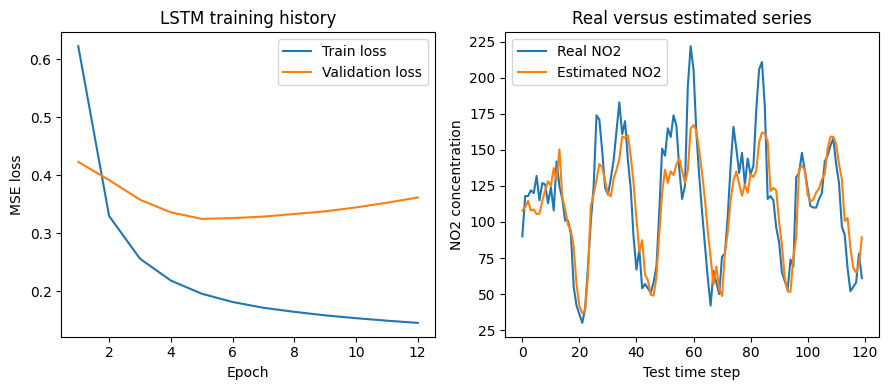

In [34]:
#@title Python Code - LSTM Sequence Training

# LSTM sequence training for air quality.
# This example uses sliding time windows.
# Civil engineering forecasting needs ordered data.

# Install exact teaching library versions.
# !pip install tensorflow==2.20.0 scikit-learn==1.8.0

# Import beginner friendly libraries.
import os
import random
import zipfile
import numpy as np; import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')

import pandas as pd
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Set deterministic seeds carefully.
random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)

# Show TensorFlow version briefly.
print("TensorFlow version:", tf.__version__)

# Report available compute device.
gpu_name = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpu_name) > 0)

# Download the air quality dataset.
!wget -q -O ./AirQualityUCI.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Extract the downloaded zip file.
if not os.path.exists("AirQualityUCI.csv"):
    with zipfile.ZipFile("AirQualityUCI.zip", "r") as zf:
        zf.extractall(".")

# Load the semicolon separated file.
df = pd.read_csv(
    "AirQualityUCI.csv",
    sep=";",
    decimal=",",
    na_values=["-200"],
)

# Remove empty unnamed columns.
df = df.dropna(axis=1, how="all")

# Build a proper datetime column.
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce",
)

# Keep rows with valid timestamps.
df = df.dropna(subset=["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)

# Select useful numeric sensor columns.
feature_cols = [
    "CO(GT)",
    "PT08.S1(CO)",
    "NMHC(GT)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH",
]

# Keep only selected columns.
keep_cols = ["Datetime"] + feature_cols
df = df[keep_cols].copy()

# Fill missing values simply.
df[feature_cols] = df[feature_cols].interpolate(limit_direction="both")
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

# Use a smaller clean subset.
df = df.iloc[:2500].copy()

# Define target pollution variable.
target_col = "NO2(GT)"

# Split chronologically into sets.
n_total = len(df)
train_end = int(n_total * 0.7)
val_end = int(n_total * 0.85)

# Compute scaling from training only.
train_stats = df.iloc[:train_end][feature_cols]
train_mean = train_stats.mean()
train_std = train_stats.std().replace(0, 1)

# Standardize all feature columns.
scaled = (df[feature_cols] - train_mean) / train_std
scaled[target_col] = (df[target_col] - train_mean[target_col]) / train_std[target_col]

# Convert to numpy arrays.
all_x = scaled[feature_cols].to_numpy(dtype=np.float32)
all_y = scaled[target_col].to_numpy(dtype=np.float32)
real_y = df[target_col].to_numpy(dtype=np.float32)

# Choose sequence window length.
window = 24

# Create sliding window sequences.
def make_sequences(x_data, y_data, y_real, start_i, end_i, steps):
    xs = []
    ys = []
    yr = []
    i = start_i
    while i + steps < end_i:
        xs.append(x_data[i:i + steps])
        ys.append(y_data[i + steps])
        yr.append(y_real[i + steps])
        i = i + 1
    return np.array(xs), np.array(ys), np.array(yr)

# Build train validation and test sets.
X_train, y_train, _ = make_sequences(
    all_x, all_y, real_y, 0, train_end, window
)
X_val, y_val, _ = make_sequences(
    all_x, all_y, real_y, train_end - window, val_end, window
)
X_test, y_test, y_test_real = make_sequences(
    all_x, all_y, real_y, val_end - window, n_total, window
)

# Validate sequence tensor shapes.
if X_train.ndim != 3:
    raise ValueError("Training tensor must be three dimensional.")
if len(X_train) < 50:
    raise ValueError("Dataset subset is too small.")

# Print compact dataset summary.
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# Build a small LSTM model.
inputs = tf.keras.Input(shape=(window, len(feature_cols)))
x = tf.keras.layers.LSTM(32)(inputs)
x = tf.keras.layers.Dense(16, activation="relu")(x)
outputs = tf.keras.layers.Dense(1)(x)

# Compile with Adam optimizer.
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
)

# Train silently with validation.
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=32,
    verbose=0,
)

# Predict on the test period.
pred_scaled = model.predict(X_test, verbose=0).reshape(-1)

# Convert predictions back to real units.
pred_real = pred_scaled * train_std[target_col] + train_mean[target_col]
y_test_real = y_test_real.reshape(-1)

# Compute simple evaluation metrics.
mae_value = mean_absolute_error(y_test_real, pred_real)
rmse_value = np.sqrt(mean_squared_error(y_test_real, pred_real))
print("Test MAE:", round(float(mae_value), 2))
print("Test RMSE:", round(float(rmse_value), 2))

# Prepare epoch numbers for plotting.
epochs = np.arange(1, len(history.history["loss"]) + 1)

# Create one figure with two panels.
plt.figure(figsize=(9, 4))

# Plot training and validation loss.
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history["loss"], label="Train loss")
plt.plot(epochs, history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("LSTM training history")
plt.legend()

# Plot real and estimated pollution.
plt.subplot(1, 2, 2)
show_n = min(120, len(y_test_real))
plt.plot(y_test_real[:show_n], label="Real NO2")
plt.plot(pred_real[:show_n], label="Estimated NO2")
plt.xlabel("Test time step")
plt.ylabel("NO2 concentration")
plt.title("Real versus estimated series")
plt.legend()

# Show the final teaching figure.
plt.tight_layout()
plt.show()



### **2.2. GRU Forecasting Activations**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_B/image_02_02.jpg?v=1774751197" width="250">



>* GRUs learn time patterns in engineering sequences.
>* Internal and output activations serve different roles.

>* Internal activations balance memory, updates, and stability.
>* Output activation depends on forecasting target.

>* Match activations to data and targets.
>* Consider constraints, scaling, and forecast horizon.



TensorFlow version: 2.21.0
GPU available: False
GRU uses tanh state and sigmoid gates.
Dense ReLU adds extra nonlinearity.
Linear output suits continuous forecasting.
GRU MAE and RMSE: 105.22 144.08
LSTM MAE and RMSE: 106.56 149.11


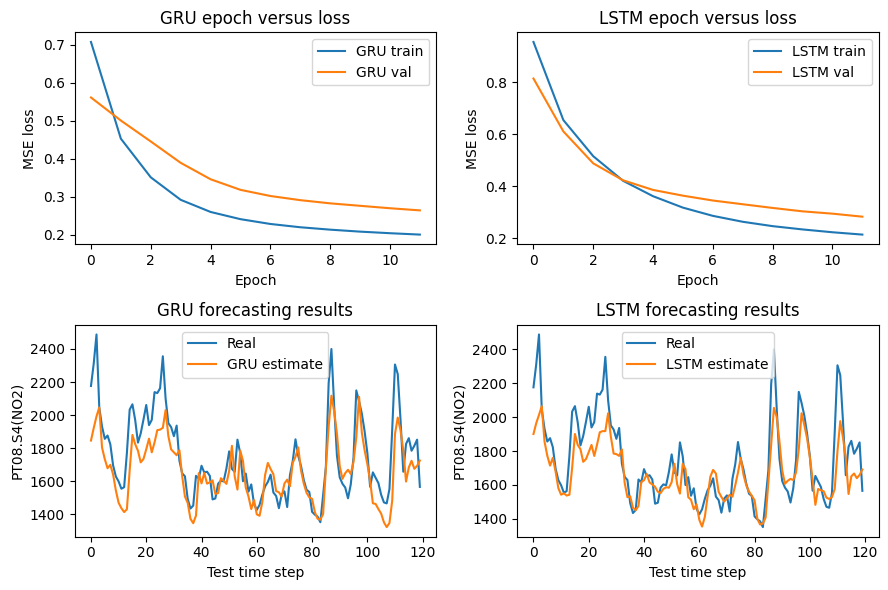

In [30]:
#@title Python Code - GRU Forecasting Activations

# This notebook teaches GRU forecasting activations.
# It uses air quality sequence data.
# LSTM results provide a simple baseline.

# !pip install tensorflow==2.20.0 scikit-learn==1.8.0

# Import small beginner friendly libraries.
import os
import zipfile
import numpy as np; import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import pandas as pd

# Import plotting and learning tools.
import matplotlib.pyplot as plt
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Set deterministic seeds for repeatability.
np.random.seed(7)
tf.random.set_seed(7)

# Show TensorFlow version briefly.
print("TensorFlow version:", tf.__version__)

# Report available training device briefly.
gpu_list = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpu_list) > 0)

# Download the air quality dataset.
!wget -q -O ./AirQualityUCI.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Unzip the downloaded dataset safely.
with zipfile.ZipFile("./AirQualityUCI.zip", "r") as zf:
    zf.extractall("./air_quality_data")

# Load the semicolon separated file.
file_path = "./air_quality_data/AirQualityUCI.csv"
df = pd.read_csv(file_path, sep=";", decimal=",")

# Remove empty trailing columns safely.
df = df.dropna(axis=1, how="all")
if "Unnamed: 15" in df.columns:
    df = df.drop(columns=["Unnamed: 15"])
if "Unnamed: 16" in df.columns:
    df = df.drop(columns=["Unnamed: 16"])

# Replace missing markers with NaN.
df = df.replace(-200, np.nan)

# Build a timestamp column.
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Keep rows with valid timestamps.
df = df.dropna(subset=["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)

# Select a forecasting target column.
target_col = "PT08.S4(NO2)"
feature_cols = [
    "CO(GT)",
    "C6H6(GT)",
    "PT08.S1(CO)",
    "PT08.S2(NMHC)",
    "PT08.S3(NOx)",
    "T",
    "RH",
    "AH",
    target_col,
]

# Keep only needed numeric columns.
data = df[feature_cols].copy()
data = data.apply(pd.to_numeric, errors="coerce")

# Fill missing values simply.
data = data.interpolate(limit_direction="both")
data = data.fillna(data.mean())

# Use a small subset for speed.
max_rows = 1500
if len(data) > max_rows:
    data = data.iloc[:max_rows].copy()

# Convert data to arrays.
values = data.values.astype("float32")
col_index = list(data.columns).index(target_col)

# Split into train and test parts.
train_size = int(len(values) * 0.8)
train_values = values[:train_size]
test_values = values[train_size:]

# Compute scaling from training only.
train_mean = train_values.mean(axis=0)
train_std = train_values.std(axis=0)
train_std[train_std == 0] = 1.0

# Scale train and test arrays.
train_scaled = (train_values - train_mean) / train_std
test_scaled = (test_values - train_mean) / train_std
all_scaled = np.vstack([train_scaled, test_scaled])

# Create supervised sequences simply.
def make_sequences(array_data, window_size, target_index):
    x_list = []
    y_list = []
    last_start = len(array_data) - window_size - 1
    for start in range(last_start):
        end = start + window_size
        x_list.append(array_data[start:end])
        y_list.append(array_data[end, target_index])
    x_arr = np.array(x_list, dtype="float32")
    y_arr = np.array(y_list, dtype="float32")
    return x_arr, y_arr

# Choose a short history window.
window = 24
X_all, y_all = make_sequences(all_scaled, window, col_index)

# Split sequences consistently.
split_point = train_size - window - 1
if split_point < 50:
    split_point = int(len(X_all) * 0.7)
X_train = X_all[:split_point]
y_train = y_all[:split_point]
X_test = X_all[split_point:]
y_test = y_all[split_point:]

# Validate sequence shapes safely.
if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError("Sequence split produced empty arrays.")

# Build a GRU forecasting model.
def build_gru_model(input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.GRU(
        24,
        activation="tanh",
        recurrent_activation="sigmoid"
    )(inputs)
    x = tf.keras.layers.Dense(12, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1, activation="linear")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer="adam", loss="mse")
    return model

# Build an LSTM baseline model.
def build_lstm_model(input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.LSTM(
        24,
        activation="tanh",
        recurrent_activation="sigmoid"
    )(inputs)
    x = tf.keras.layers.Dense(12, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1, activation="linear")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer="adam", loss="mse")
    return model

# Create both small models.
input_shape = (X_train.shape[1], X_train.shape[2])
gru_model = build_gru_model(input_shape)
lstm_model = build_lstm_model(input_shape)

# Train the GRU model quietly.
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=12,
    batch_size=32,
    verbose=0
)

# Train the LSTM baseline quietly.
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=12,
    batch_size=32,
    verbose=0
)

# Predict scaled target values.
gru_pred_scaled = gru_model.predict(X_test, verbose=0).reshape(-1)
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0).reshape(-1)

# Convert predictions back to original units.
target_mean = train_mean[col_index]
target_std = train_std[col_index]
y_test_real = y_test * target_std + target_mean
gru_pred_real = gru_pred_scaled * target_std + target_mean
lstm_pred_real = lstm_pred_scaled * target_std + target_mean

# Compute simple forecasting metrics.
gru_mae = mean_absolute_error(y_test_real, gru_pred_real)
lstm_mae = mean_absolute_error(y_test_real, lstm_pred_real)
gru_rmse = np.sqrt(mean_squared_error(y_test_real, gru_pred_real))
lstm_rmse = np.sqrt(mean_squared_error(y_test_real, lstm_pred_real))

# Print a short activation explanation.
print("GRU uses tanh state and sigmoid gates.")
print("Dense ReLU adds extra nonlinearity.")
print("Linear output suits continuous forecasting.")
print("GRU MAE and RMSE:", round(gru_mae, 2), round(gru_rmse, 2))
print("LSTM MAE and RMSE:", round(lstm_mae, 2), round(lstm_rmse, 2))

# Create one figure with four panels.
plt.figure(figsize=(9, 6))

# Plot epoch versus loss curves.
plt.subplot(2, 2, 1)
plt.plot(gru_history.history["loss"], label="GRU train")
plt.plot(gru_history.history["val_loss"], label="GRU val")
plt.title("GRU epoch versus loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()

# Plot LSTM epoch versus loss curves.
plt.subplot(2, 2, 2)
plt.plot(lstm_history.history["loss"], label="LSTM train")
plt.plot(lstm_history.history["val_loss"], label="LSTM val")
plt.title("LSTM epoch versus loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()

# Plot GRU real versus estimated values.
show_n = 120
plt.subplot(2, 2, 3)
plt.plot(y_test_real[:show_n], label="Real")
plt.plot(gru_pred_real[:show_n], label="GRU estimate")
plt.title("GRU forecasting results")
plt.xlabel("Test time step")
plt.ylabel(target_col)
plt.legend()

# Plot LSTM real versus estimated values.
plt.subplot(2, 2, 4)
plt.plot(y_test_real[:show_n], label="Real")
plt.plot(lstm_pred_real[:show_n], label="LSTM estimate")
plt.title("LSTM forecasting results")
plt.xlabel("Test time step")
plt.ylabel(target_col)
plt.legend()

# Finish the single required figure.
plt.tight_layout()
plt.show()



### **2.3. LSTM GRU Comparison**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_B/image_02_03.jpg?v=1774751243" width="250">



>* Both model time-based civil engineering patterns.
>* LSTM is complex; GRU is simpler.

>* GRUs train faster for shorter sequences.
>* LSTMs help with longer dependencies.

>* Choose models using data and context.
>* Test both for reliability and fit.



TensorFlow version: 2.21.0
Train sequences: 1976
Test sequences: 476
LSTM parameters: 3865
GRU parameters: 3049
LSTM test MAE: 0.473
GRU test MAE: 0.504


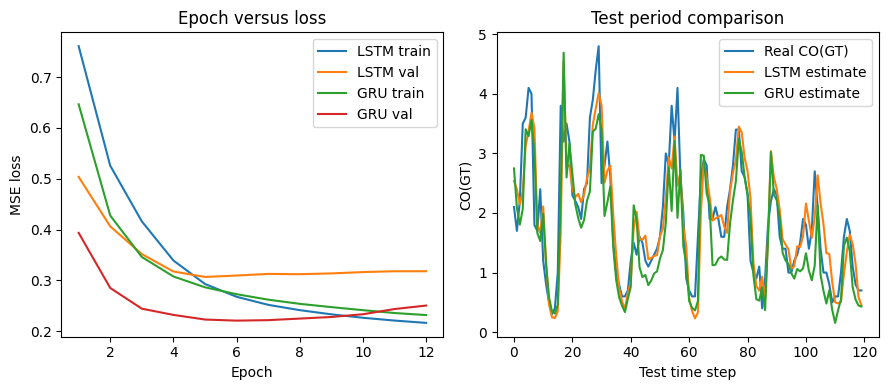

In [31]:
#@title Python Code - LSTM GRU Comparison

# Compare recurrent models for air quality.
# This notebook uses simple sequence forecasting.
# Civil engineering students can inspect differences.

# !pip install tensorflow==2.20.0 scikit-learn==1.8.0

import os
import random
import zipfile
import numpy as np; import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')

import pandas as pd
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# Set deterministic seeds carefully.
random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)

# Show TensorFlow version briefly.
print("TensorFlow version:", tf.__version__)

# Download the air quality dataset.
!wget -q -O ./AirQualityUCI.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Extract the downloaded zip file.
with zipfile.ZipFile("./AirQualityUCI.zip", "r") as zf:
    zf.extractall("./air_quality_data")

# Load the semicolon separated file.
file_path = "./air_quality_data/AirQualityUCI.csv"
df = pd.read_csv(file_path, sep=";", decimal=",")

# Remove empty trailing columns safely.
df = df.dropna(axis=1, how="all")

# Keep rows with valid target values.
df = df[df["CO(GT)"] != -200].copy()

# Build a timestamp column.
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Drop rows with invalid timestamps.
df = df.dropna(subset=["Datetime"]).copy()

# Sort records by time order.
df = df.sort_values("Datetime").reset_index(drop=True)

# Select a small numeric feature set.
feature_cols = [
    "PT08.S1(CO)",
    "NMHC(GT)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH"
]

# Keep available columns only.
usable_cols = []
for col in feature_cols:
    if col in df.columns:
        usable_cols.append(col)

# Replace missing markers with NaN.
for col in usable_cols + ["CO(GT)"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df.loc[df[col] == -200, col] = np.nan

# Keep a compact subset for speed.
df = df[["Datetime"] + usable_cols + ["CO(GT)"]].copy()
df = df.iloc[:2500].copy()

# Fill missing values by interpolation.
df[usable_cols + ["CO(GT)"]] = df[usable_cols + ["CO(GT)"]].interpolate(
    method="linear",
    limit_direction="both"
)

# Drop any remaining missing rows.
df = df.dropna().reset_index(drop=True)

# Stop early if data are insufficient.
if len(df) < 200:
    raise ValueError("Dataset became too small for sequences.")

# Split data into train and test.
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

# Compute scaling statistics from training.
feature_mean = train_df[usable_cols].mean()
feature_std = train_df[usable_cols].std().replace(0, 1)
target_mean = train_df["CO(GT)"].mean()
target_std = train_df["CO(GT)"].std()
if target_std == 0:
    target_std = 1.0

# Scale train and test values.
train_x_scaled = (train_df[usable_cols] - feature_mean) / feature_std
test_x_scaled = (test_df[usable_cols] - feature_mean) / feature_std
train_y_scaled = (train_df["CO(GT)"] - target_mean) / target_std
test_y_scaled = (test_df["CO(GT)"] - target_mean) / target_std

# Create simple rolling sequences.
def make_sequences(x_frame, y_series, window):
    x_values = x_frame.to_numpy(dtype=np.float32)
    y_values = y_series.to_numpy(dtype=np.float32)
    x_list = []
    y_list = []
    i = window
    while i < len(x_values):
        x_list.append(x_values[i - window:i])
        y_list.append(y_values[i])
        i = i + 1
    x_array = np.array(x_list, dtype=np.float32)
    y_array = np.array(y_list, dtype=np.float32)
    return x_array, y_array

# Build train and test sequences.
window = 24
x_train, y_train = make_sequences(train_x_scaled, train_y_scaled, window)
x_test, y_test = make_sequences(test_x_scaled, test_y_scaled, window)

# Validate sequence shapes safely.
if len(x_train) == 0 or len(x_test) == 0:
    raise ValueError("Sequence creation failed.")

# Report compact dataset information.
print("Train sequences:", x_train.shape[0])
print("Test sequences:", x_test.shape[0])

# Build a small LSTM model.
def build_lstm_model(input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.LSTM(24)(inputs)
    x = tf.keras.layers.Dense(12, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse")
    return model

# Build a small GRU model.
def build_gru_model(input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.GRU(24)(inputs)
    x = tf.keras.layers.Dense(12, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse")
    return model

# Create both comparison models.
input_shape = (x_train.shape[1], x_train.shape[2])
lstm_model = build_lstm_model(input_shape)
gru_model = build_gru_model(input_shape)

# Train the LSTM model silently.
lstm_history = lstm_model.fit(
    x_train,
    y_train,
    epochs=12,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Train the GRU model silently.
gru_history = gru_model.fit(
    x_train,
    y_train,
    epochs=12,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Predict on the test period.
lstm_pred_scaled = lstm_model.predict(x_test, verbose=0).reshape(-1)
gru_pred_scaled = gru_model.predict(x_test, verbose=0).reshape(-1)

# Convert predictions back to original units.
y_test_real = y_test * target_std + target_mean
lstm_pred_real = lstm_pred_scaled * target_std + target_mean
gru_pred_real = gru_pred_scaled * target_std + target_mean

# Compute simple comparison metrics.
lstm_mae = mean_absolute_error(y_test_real, lstm_pred_real)
gru_mae = mean_absolute_error(y_test_real, gru_pred_real)

# Print compact model comparison lines.
print("LSTM parameters:", lstm_model.count_params())
print("GRU parameters:", gru_model.count_params())
print("LSTM test MAE:", round(float(lstm_mae), 3))
print("GRU test MAE:", round(float(gru_mae), 3))

# Prepare epochs for plotting.
epochs = np.arange(1, len(lstm_history.history["loss"]) + 1)

# Create one figure with two panels.
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Plot training loss comparison.
axes[0].plot(epochs, lstm_history.history["loss"], label="LSTM train")
axes[0].plot(epochs, lstm_history.history["val_loss"], label="LSTM val")
axes[0].plot(epochs, gru_history.history["loss"], label="GRU train")
axes[0].plot(epochs, gru_history.history["val_loss"], label="GRU val")
axes[0].set_title("Epoch versus loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()

# Plot real and estimated test values.
show_n = min(120, len(y_test_real))
axes[1].plot(y_test_real[:show_n], label="Real CO(GT)")
axes[1].plot(lstm_pred_real[:show_n], label="LSTM estimate")
axes[1].plot(gru_pred_real[:show_n], label="GRU estimate")
axes[1].set_title("Test period comparison")
axes[1].set_xlabel("Test time step")
axes[1].set_ylabel("CO(GT)")
axes[1].legend()

# Finish the single required plot.
plt.tight_layout()
plt.show()



## **3. Advanced TensorFlow Components**

### **3.1. Feature Map Reconstruction**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_B/image_03_01.jpg?v=1774751295" width="250">



>* Reconstruction restores spatial detail from compressed features.
>* UpSampling2D and Conv2DTranspose differ in output quality.

>* UpSampling2D resizes simply; Conv2DTranspose learns details.
>* Combine methods carefully to refine outputs.

>* Activations control reconstruction behavior and output range.
>* Reusable blocks improve consistency, stability, and accuracy.



### **3.2. Architecture Selection**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_B/image_03_02.jpg?v=1774751333" width="250">



>* Match architecture to data and task.
>* Choose reconstruction layers by output detail.

>* Activations shape learning, nonlinearity, and outputs.
>* Reusable blocks improve consistency and maintainability.

>* Balance accuracy, robustness, cost, and deployment needs.
>* Compare architectures for stability and workflow fit.



TensorFlow version: 2.21.0
Running on: CPU
CNN test accuracy: 0.25
CIFAR confusion matrix shape: (10, 10)
Sequence test points: 156
CNN fits images; GRU fits ordered sensor sequences.


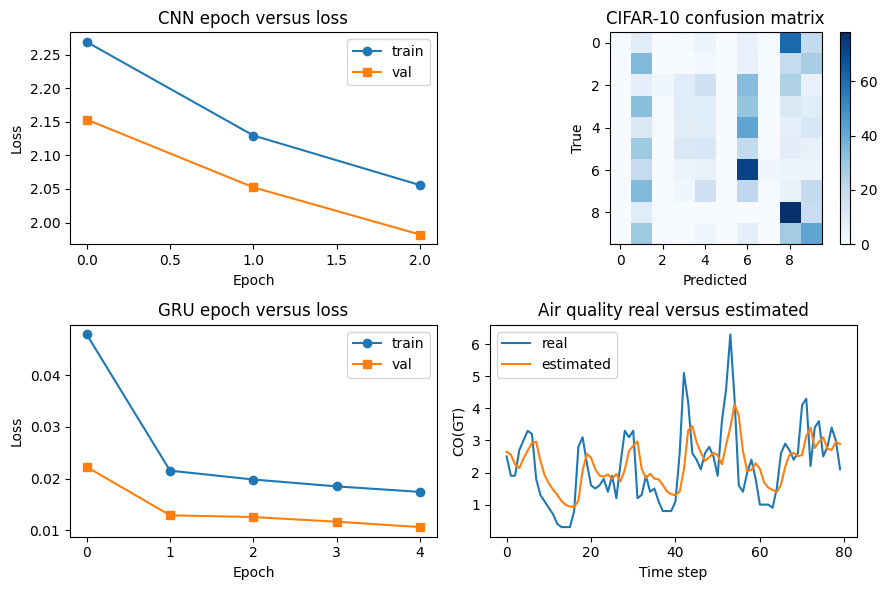

In [ ]:
#@title Python Code - Architecture Selection

# This notebook shows architecture selection.
# Civil engineering examples guide choices.
# Small models keep runtime manageable.

# !pip install tensorflow==2.20.0.

import os
import random
import zipfile
import numpy as np; import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')

import pandas as pd
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Set deterministic seeds carefully.
np.random.seed(7)
random.seed(7)
tf.random.set_seed(7)

# Report TensorFlow version briefly.
print("TensorFlow version:", tf.__version__)

# Detect available hardware safely.
gpu_list = tf.config.list_physical_devices("GPU")
device_name = "GPU" if len(gpu_list) > 0 else "CPU"
print("Running on:", device_name)

# Load a small CIFAR subset.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train[:5000].astype("float32") / 255.0
x_test = x_test[:1000].astype("float32") / 255.0

y_train = y_train[:5000].reshape(-1)
y_test = y_test[:1000].reshape(-1)
class_names = ["airplane", "auto", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

# Build a small CNN model.
cnn_inputs = tf.keras.Input(shape=(32, 32, 3))
x = tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same")(cnn_inputs)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = tf.keras.layers.UpSampling2D(size=(1, 1))(x)
x = tf.keras.layers.Conv2DTranspose(32, 3, activation="relu", padding="same")(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(32, activation="relu")(x)
cnn_outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

cnn_model = tf.keras.Model(cnn_inputs, cnn_outputs)
cnn_model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

# Train the CNN silently.
cnn_history = cnn_model.fit(x_train, y_train,
                            validation_split=0.2,
                            epochs=3,
                            batch_size=64,
                            verbose=0)

# Predict test labels safely.
cnn_probs = cnn_model.predict(x_test, verbose=0)
cnn_pred = np.argmax(cnn_probs, axis=1)
cnn_cm = confusion_matrix(y_test, cnn_pred)
cnn_acc = float(np.mean(cnn_pred == y_test))

# Download air quality data.
!wget -q -O ./AirQualityUCI.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Extract the downloaded archive.
if not os.path.exists("AirQualityUCI.csv"):
    with zipfile.ZipFile("AirQualityUCI.zip", "r") as zip_ref:
        zip_ref.extractall(".")

# Read and clean the dataset.
air = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")
air = air.dropna(axis=1, how="all")
air = air.iloc[:-2].copy()

# Replace missing markers carefully.
for col in air.columns:
    if col not in ["Date", "Time"]:
        air[col] = pd.to_numeric(air[col], errors="coerce")
        air[col] = air[col].replace(-200, np.nan)

# Create a datetime column.
air["Datetime"] = pd.to_datetime(
    air["Date"] + " " + air["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

air = air.sort_values("Datetime")
air = air.reset_index(drop=True)
air = air.dropna(subset=["Datetime"])

# Select one forecasting signal.
target_name = "CO(GT)"
series = air[target_name].interpolate(limit_direction="both")
series = series.fillna(series.mean())
series = series.astype("float32")

# Keep a small sequence subset.
series = series.iloc[:800].reset_index(drop=True)
series_values = series.to_numpy()
series_min = float(np.min(series_values))
series_max = float(np.max(series_values))

# Scale values to zero one.
scaled = (series_values - series_min) / (series_max - series_min + 1e-8)
window = 24
X_seq = []
y_seq = []

# Build sliding windows simply.
for i in range(len(scaled) - window):
    X_seq.append(scaled[i:i + window])
    y_seq.append(scaled[i + window])

X_seq = np.array(X_seq, dtype="float32")
y_seq = np.array(y_seq, dtype="float32")
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

# Split train and test sets.
split_index = int(0.8 * len(X_seq))
X_train_seq = X_seq[:split_index]
y_train_seq = y_seq[:split_index]

X_test_seq = X_seq[split_index:]
y_test_seq = y_seq[split_index:]

# Build a small GRU model.
seq_inputs = tf.keras.Input(shape=(window, 1))
z = tf.keras.layers.GRU(16, activation="tanh")(seq_inputs)
z = tf.keras.layers.Dense(8, activation="relu")(z)
seq_outputs = tf.keras.layers.Dense(1, activation="linear")(z)

seq_model = tf.keras.Model(seq_inputs, seq_outputs)
seq_model.compile(optimizer="adam", loss="mse")

# Train the sequence model silently.
seq_history = seq_model.fit(X_train_seq, y_train_seq,
                            validation_split=0.2,
                            epochs=5,
                            batch_size=32,
                            verbose=0)

# Predict and invert scaling.
seq_pred_scaled = seq_model.predict(X_test_seq, verbose=0).reshape(-1)
seq_true = y_test_seq * (series_max - series_min) + series_min
seq_pred = seq_pred_scaled * (series_max - series_min) + series_min

# Print short teaching conclusions.
print("CNN test accuracy:", round(cnn_acc, 3))
print("CIFAR confusion matrix shape:", cnn_cm.shape)
print("Sequence test points:", len(seq_true))
print("CNN fits images; GRU fits ordered sensor sequences.")

# Create one figure with four panels.
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# Plot CNN training losses.
axes[0, 0].plot(cnn_history.history["loss"], marker="o", label="train")
axes[0, 0].plot(cnn_history.history["val_loss"], marker="s", label="val")
axes[0, 0].set_title("CNN epoch versus loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# Plot the confusion matrix.
image = axes[0, 1].imshow(cnn_cm, cmap="Blues")
axes[0, 1].set_title("CIFAR-10 confusion matrix")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("True")
fig.colorbar(image, ax=axes[0, 1], fraction=0.046)

# Plot sequence training losses.
axes[1, 0].plot(seq_history.history["loss"], marker="o", label="train")
axes[1, 0].plot(seq_history.history["val_loss"], marker="s", label="val")
axes[1, 0].set_title("GRU epoch versus loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

# Plot real versus estimated values.
show_n = min(80, len(seq_true))
axes[1, 1].plot(seq_true[:show_n], label="real")
axes[1, 1].plot(seq_pred[:show_n], label="estimated")
axes[1, 1].set_title("Air quality real versus estimated")
axes[1, 1].set_xlabel("Time step")
axes[1, 1].set_ylabel(target_name)
axes[1, 1].legend()

# Finish the single required figure.
plt.tight_layout()
plt.show()



### **3.3. Model Saving Evaluation**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_B/image_03_03.jpg?v=1774751386" width="250">



>* Save models to preserve architecture and behavior.
>* Evaluate reloaded models on unseen conditions.

>* Evaluate beyond scores for engineering detail.
>* Saved models must reload consistently and reliably.

>* Saved models support comparison across project lifecycles.
>* Evaluation ensures reliable, deployable, transparent model choices.



TensorFlow version: 2.21.0
Sklearn metrics version ready.
GPU available: False
Reloaded MNIST accuracy: 0.472
Reloaded concrete MAE: 10.511
Reloaded concrete RMSE: 13.279
Reloaded concrete R2: 0.335
Saved models preserve architecture and learned weights.
Reloading supports repeatable engineering evaluation.


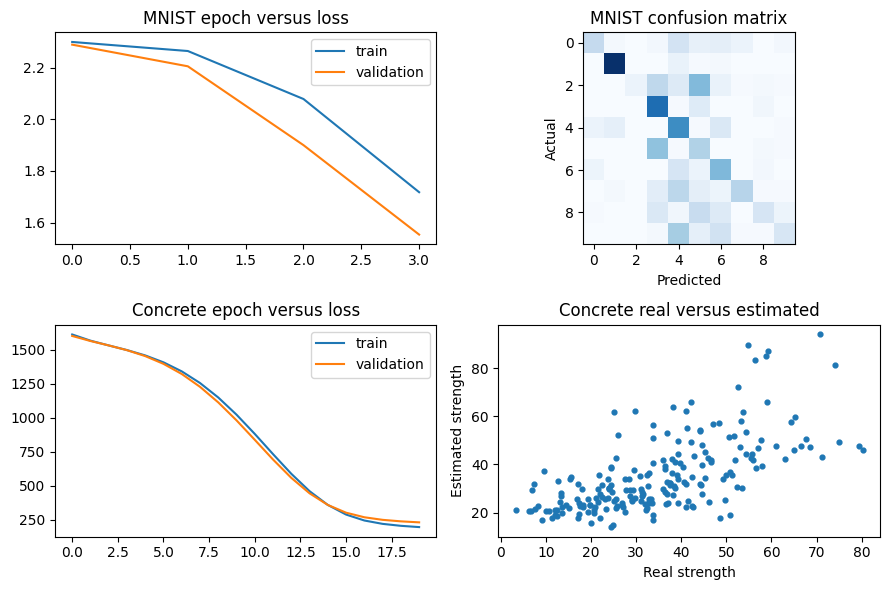

In [33]:
#@title Python Code - Model Saving Evaluation

# Saved models support reproducible engineering workflows.
# This notebook shows saving and reloading models.
# Advanced layers can still be preserved reliably.

# !pip install pandas==3.0.0 scikit-learn==1.8.0 xlrd==2.0.1

import os
import random
import numpy as np; import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Set deterministic seeds carefully.
random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)

# Print short version information.
print("TensorFlow version:", tf.__version__)
print("Sklearn metrics version ready.")

# Detect available compute device.
gpu_name = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpu_name) > 0)

# Load a small MNIST subset.
mnist = tf.keras.datasets.mnist.load_data()
(x_train, y_train), (x_test, y_test) = mnist

# Keep runtime small and safe.
x_train = x_train[:4000].astype("float32") / 255.0
x_test = x_test[:1000].astype("float32") / 255.0
y_train = y_train[:4000]
y_test = y_test[:1000]

# Add channel dimension explicitly.
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Validate image shapes simply.
assert x_train.shape[1:] == (28, 28, 1)
assert x_test.shape[1:] == (28, 28, 1)

# Build a reusable convolution block.
def conv_block(inputs, filters):
    x = tf.keras.layers.Conv2D(
        filters, 3, padding="same"
    )(inputs)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    return x

# Build an advanced Functional API model.
inputs = tf.keras.Input(shape=(28, 28, 1))
x = conv_block(inputs, 16)
x = conv_block(x, 32)

# Use advanced reconstruction layers.
x = tf.keras.layers.UpSampling2D(size=(2, 2))(x)
x = tf.keras.layers.Conv2DTranspose(
    16, 3, padding="same", activation="relu"
)(x)

# Finish classification head cleanly.
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(10, activation="softmax")(x)
mnist_model = tf.keras.Model(inputs, outputs)

# Compile the classification model.
mnist_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[]
)

# Train silently for few epochs.
history_mnist = mnist_model.fit(
    x_train, y_train,
    epochs=4, batch_size=64,
    validation_split=0.2, verbose=0
)

# Save and reload the model.
mnist_path = "mnist_saved.keras"
mnist_model.save(mnist_path)
reloaded_mnist = tf.keras.models.load_model(mnist_path)

# Predict with the reloaded model.
mnist_probs = reloaded_mnist.predict(x_test, verbose=0)
mnist_pred = np.argmax(mnist_probs, axis=1)

# Evaluate using sklearn metrics only.
mnist_acc = accuracy_score(y_test, mnist_pred)
mnist_cm = confusion_matrix(y_test, mnist_pred)
print("Reloaded MNIST accuracy:", round(mnist_acc, 4))

# Download the concrete dataset.
!wget -q -O ./Concrete_Data.xls https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls

# Load the concrete spreadsheet.
concrete_df = pd.read_excel("Concrete_Data.xls")
concrete_df = concrete_df.dropna()

# Prepare regression arrays safely.
X = concrete_df.iloc[:, :-1].astype("float32").values
y = concrete_df.iloc[:, -1].astype("float32").values

# Split data for regression.
X_train, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, random_state=7
)

# Standardize using training statistics.
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0) + 1e-6
X_train = (X_train - X_mean) / X_std
X_test_r = (X_test_r - X_mean) / X_std

# Validate tabular feature count.
assert X_train.shape[1] == 8
assert len(y_train_r) > 100

# Build a reusable dense block.
def dense_block(inputs, units):
    x = tf.keras.layers.Dense(units)(inputs)
    x = tf.keras.layers.Activation("relu")(x)
    return x

# Build a regression Functional API model.
reg_inputs = tf.keras.Input(shape=(8,))
r = dense_block(reg_inputs, 32)
r = dense_block(r, 16)
reg_outputs = tf.keras.layers.Dense(1)(r)
reg_model = tf.keras.Model(reg_inputs, reg_outputs)

# Compile the regression model.
reg_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[]
)

# Train silently for few epochs.
history_reg = reg_model.fit(
    X_train, y_train_r,
    epochs=20, batch_size=32,
    validation_split=0.2, verbose=0
)

# Save and reload regression model.
reg_path = "concrete_saved.keras"
reg_model.save(reg_path)
reloaded_reg = tf.keras.models.load_model(reg_path)

# Predict with the reloaded regressor.
y_pred_r = reloaded_reg.predict(X_test_r, verbose=0).ravel()
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = mean_squared_error(y_test_r, y_pred_r) ** 0.5

# Report compact regression metrics.
r2 = r2_score(y_test_r, y_pred_r)
print("Reloaded concrete MAE:", round(mae, 3))
print("Reloaded concrete RMSE:", round(rmse, 3))
print("Reloaded concrete R2:", round(r2, 3))

# Explain reproducible workflow briefly.
print("Saved models preserve architecture and learned weights.")
print("Reloading supports repeatable engineering evaluation.")

# Create one figure with four panels.
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# Plot MNIST training losses.
axes[0, 0].plot(history_mnist.history["loss"], label="train")
axes[0, 0].plot(history_mnist.history["val_loss"], label="validation")
axes[0, 0].set_title("MNIST epoch versus loss")
axes[0, 0].legend()

# Plot MNIST confusion matrix.
axes[0, 1].imshow(mnist_cm, cmap="Blues")
axes[0, 1].set_title("MNIST confusion matrix")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Actual")

# Plot concrete training losses.
axes[1, 0].plot(history_reg.history["loss"], label="train")
axes[1, 0].plot(history_reg.history["val_loss"], label="validation")
axes[1, 0].set_title("Concrete epoch versus loss")
axes[1, 0].legend()

# Plot real versus estimated strengths.
axes[1, 1].scatter(y_test_r, y_pred_r, s=12)
axes[1, 1].set_title("Concrete real versus estimated")
axes[1, 1].set_xlabel("Real strength")
axes[1, 1].set_ylabel("Estimated strength")

# Finish the single required figure.
plt.tight_layout()
plt.show()



# <font color="#418FDE" size="6.5" uppercase>**Functional API & TensorFlow Architectures**</font>

In this lecture, you learned to:
- Build neural network models using the TensorFlow Functional API for flexible CE workflows. 
- Implement recurrent neural network architectures such as LSTM and GRU for sequence and time-series CE data. 
- Select and apply advanced TensorFlow layers and architecture components for specialized modeling tasks. 

In spring & fall semesters, the next Module, Module 7, will be the Midterm week with no lectures. In the summer semesters, we skip Module 7 and focus on Module 8, "ML Major Challenges and Remedies." For the summer Midterm, please follow the course announcements and the course outline. 